### CardioRisk ML
#### Modelling & Model Comparison

In this notebook I train, evaluate, and compare six machine learning algorithms
for the cardiovascular risk prediction task.

My objective is to select the model with the best clinical performance.
In preventive screening, the cost of a false negative substantially outweighs 
the cost of a false positive. For this reason Recall carries the greatest weight in the
final evaluation, complemented by ROC-AUC to measure overall class separability.

#### Models evaluated

| Model | Type | Rationale |
|---|---|---|
| Logistic Regression | Linear | Interpretable baseline |
| Decision Tree | Tree | Fully interpretable, useful as a reference |
| Random Forest | Bagging ensemble | Robust and stable, low variance |
| Gradient Boosting | Boosting ensemble | High predictive power |
| XGBoost | Optimised boosting | State-of-the-art on tabular data |
| SVM | Margin classifier | Effective in high-dimensional spaces |

In [1]:
"""
Environment setup.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm          import SVC
from xgboost              import XGBClassifier

# Metrics & validation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Paths
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../data/eda_charts")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Constants
RANDOM_STATE = 42

# Colour palette
COLOR_LOW  = "#2ECC71"
COLOR_HIGH = "#E74C3C"
MODEL_COLORS = ["#3498DB", "#E67E22", "#2ECC71", "#9B59B6", "#E74C3C", "#1ABC9C"]

# Plot defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

def save_plot(name: str) -> None:
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

#### Data Loading

In [2]:
"""
Load the preprocessed training and test sets from Notebook 03.
"""

train = pd.read_csv(PROCESSED_DIR / "train_balanced.csv")
test  = pd.read_csv(PROCESSED_DIR / "test.csv")

X_train = train.drop(columns=["cardiovascular_risk"])
y_train = train["cardiovascular_risk"]

X_test = test.drop(columns=["cardiovascular_risk"])
y_test = test["cardiovascular_risk"]

print(f"Train : {X_train.shape}  |  high risk: {y_train.mean() * 100:.1f}%")
print(f"Test  : {X_test.shape}   |  high risk: {y_test.mean() * 100:.1f}%")

# Load the original (pre-SMOTE) training set for cross-validation.
# Using SMOTE-balanced data in CV inflates CV-AUC because synthetic samples
# from the same folds leak into evaluation. The original distribution gives
# an unbiased CV estimate.
train_orig    = pd.read_csv(PROCESSED_DIR / "train_original.csv")
X_train_orig  = train_orig.drop(columns=["cardiovascular_risk"])
y_train_orig  = train_orig["cardiovascular_risk"]

Train : (9558, 37)  |  high risk: 50.0%
Test  : (2000, 37)   |  high risk: 40.2%


#### Model Definitions

Hyperparameters were refined through manual sensitivity analysis.
class_weight='balanced' in linear and forest models weights each class
by the inverse of its frequency, a complementary guard against imbalance on top of SMOTE.

In [3]:
"""
Instantiate all six classifiers with tuned hyperparameters.
"""

models = {
    "Logistic Regression": LogisticRegression(
        C=0.5,
        max_iter=1_000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
    ),
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,   # required for ROC-AUC computation
        random_state=RANDOM_STATE,
    ),
}

print(f"{len(models)} models defined.")
for name in models:
    print(f"  • {name}")

6 models defined.
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • Gradient Boosting
  • XGBoost
  • SVM


#### Training and Evaluation Loop

Each model is trained on the balanced training set and evaluated on the test
set with its natural class distribution. Five-fold stratified cross-validation
estimates stability and guards against lucky train/test splits.

In [4]:
"""
Train all models and compute evaluation metrics.
"""

results        = []
predictions    = {}
probabilities  = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

header = f"{'Model':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>7}  {'CV-AUC (mean±std)':>18}"
print(header)
print("-" * len(header))

for name, model in models.items():

    # Fit and predict
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name]   = y_pred
    probabilities[name] = y_proba

    # Test-set metrics 
    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test,   y_pred)
    f1   = f1_score(y_test,       y_pred)
    auc  = roc_auc_score(y_test,  y_proba)

    # Cross-validation AUC
    # CV on unbalanced original data to avoid SMOTE leakage between folds.
    cv_scores = cross_val_score(
        model, X_train_orig, y_train_orig,
        cv=cv, scoring="roc_auc", n_jobs=-1,
    )

    results.append({
        "Model":     name,
        "Accuracy":  acc,
        "Precision": prec,
        "Recall":    rec,
        "F1":        f1,
        "AUC":       auc,
        "CV-AUC":    cv_scores.mean(),
        "CV-STD":    cv_scores.std(),
    })

    print(
        f"  {name:<23} {acc:>6.3f} {prec:>6.3f} {rec:>6.3f} "
        f"{f1:>6.3f} {auc:>7.3f}  "
        f"{cv_scores.mean():>6.3f} ± {cv_scores.std():.3f}"
    )

df_results = pd.DataFrame(results)
print("\nTraining complete.")

Model                        Acc   Prec    Rec     F1     AUC   CV-AUC (mean±std)
---------------------------------------------------------------------------------
  Logistic Regression      0.793  0.742  0.747  0.744   0.866   0.875 ± 0.007
  Decision Tree            0.756  0.695  0.703  0.699   0.826   0.823 ± 0.010
  Random Forest            0.782  0.733  0.722  0.727   0.854   0.858 ± 0.012
  Gradient Boosting        0.784  0.746  0.702  0.723   0.863   0.860 ± 0.008
  XGBoost                  0.796  0.766  0.712  0.738   0.862   0.861 ± 0.007
  SVM                      0.792  0.743  0.738  0.741   0.856   0.860 ± 0.008

Training complete.


#### Metric Comparison

I highlight the best-performing model in each metric with a gold star and
full opacity. The bottom of each chart shows the minimum metric value so
the y-axis is scaled to maximise visual discrimination between models.

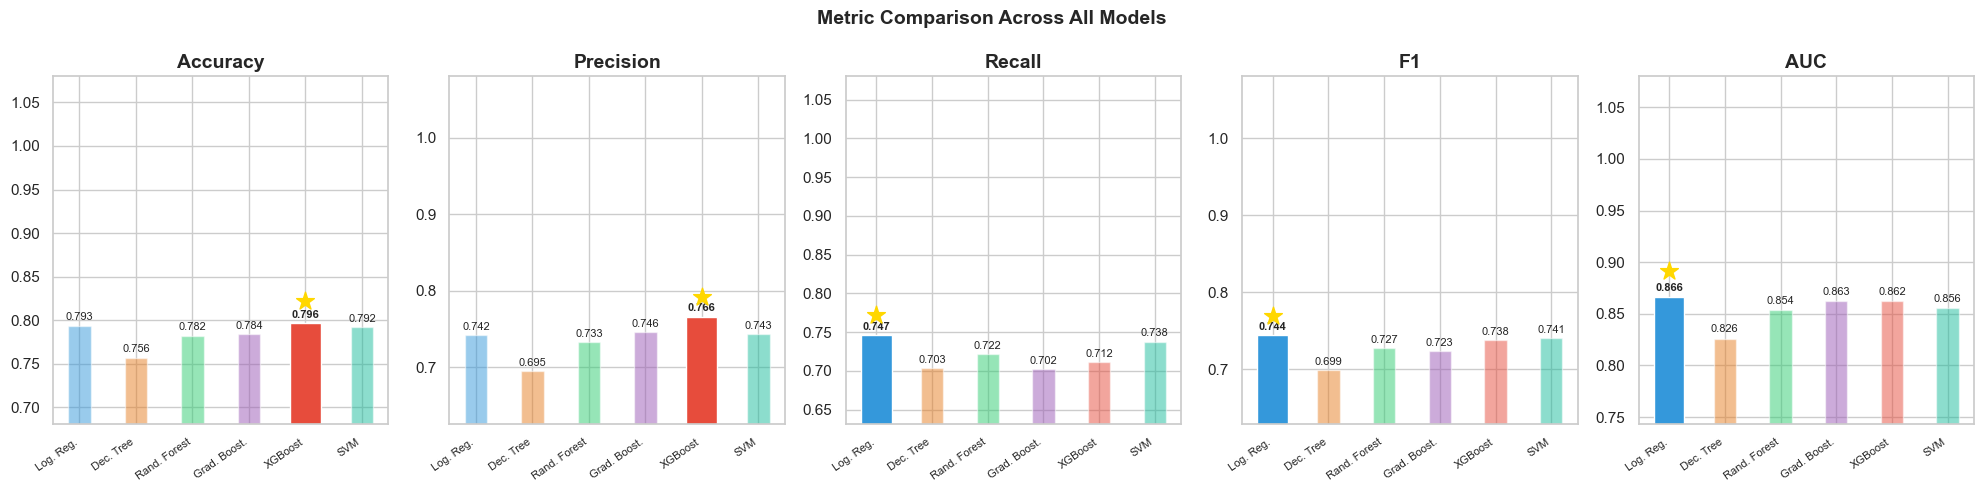

In [5]:
"""
Bar chart comparison across five evaluation metrics.
"""

short_names = ["Log. Reg.", "Dec. Tree", "Rand. Forest",
               "Grad. Boost.", "XGBoost", "SVM"]
metrics     = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Metric Comparison Across All Models",
             fontsize=14, fontweight="bold")

for ax, metric in zip(axes, metrics):
    vals = df_results[metric].values
    best = np.argmax(vals)

    for i, (v, color) in enumerate(zip(vals, MODEL_COLORS)):
        ax.bar(
            i, v,
            color=color,
            alpha=1.0 if i == best else 0.50,
            width=0.55 if i == best else 0.40,
            edgecolor="white",
        )
        ax.text(
            i, v + 0.004, f"{v:.3f}",
            ha="center", va="bottom",
            fontsize=8,
            fontweight="bold" if i == best else "normal",
        )

    # Gold star marks the winner
    ax.scatter(best, vals[best] + 0.025,
               marker="*", color="gold", s=180, zorder=5)

    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(vals.min() * 0.90, 1.08)
    ax.set_title(metric, fontweight="bold")

plt.tight_layout()
save_plot("13_metric_comparison")
plt.show()

#### ROC Curves

I draw all six curves on the same axes so their trade-offs are directly
comparable. The shaded region in the upper-left corner marks the ideal
operating zone for a clinical screening tool.

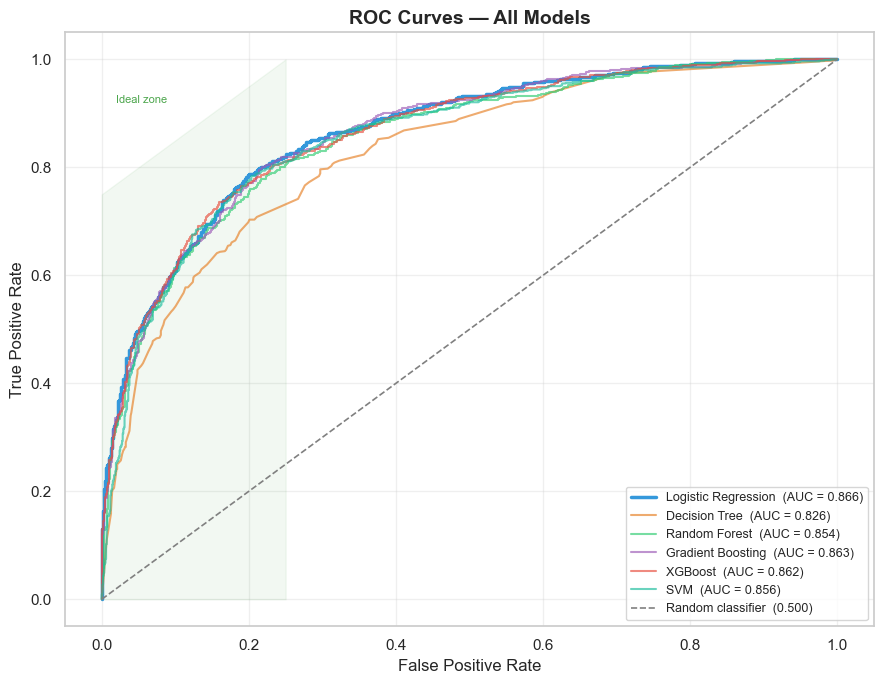

Best AUC model: Logistic Regression


In [6]:
"""
ROC curves for all models with the best-AUC model highlighted.
"""

best_model_name = df_results.loc[df_results["AUC"].idxmax(), "Model"]

fig, ax = plt.subplots(figsize=(9, 7))

for (name, y_proba), color in zip(probabilities.items(), MODEL_COLORS):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc          = roc_auc_score(y_test, y_proba)
    is_best      = name == best_model_name
    ax.plot(
        fpr, tpr,
        color=color,
        linewidth=2.5 if is_best else 1.5,
        alpha=1.0     if is_best else 0.65,
        label=f"{name}  (AUC = {auc:.3f})",
    )

ax.plot([0, 1], [0, 1], "--", color="gray",
        linewidth=1.2, label="Random classifier  (0.500)")

# Ideal operating zone for clinical screening
ax.fill_between([0, 0.25], [0.75, 1.0],
                alpha=0.05, color="green")
ax.text(0.02, 0.92, "Ideal zone",
        fontsize=8, color="green", alpha=0.7)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot("14_roc_curves")
plt.show()

print(f"Best AUC model: {best_model_name}")

#### Confusion Matrix

Each cell shows the absolute count and the row percentage. The red-bordered
cell highlights false negatives, the clinically most costly error in a preventive screening context.

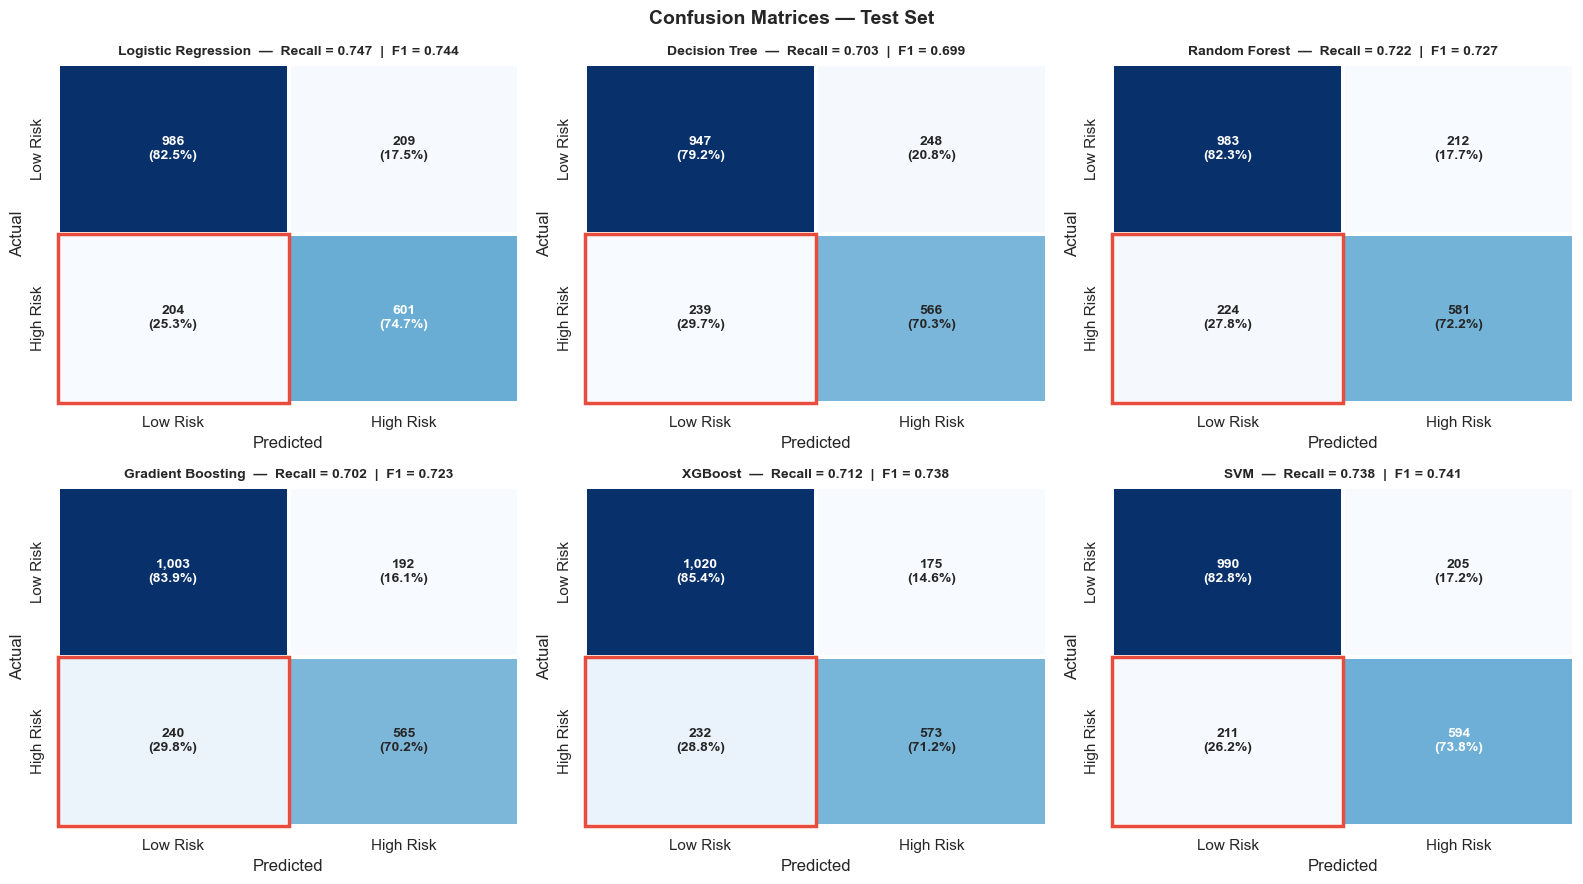

In [7]:
"""
Confusion matrix for all six models on the test set.
"""

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Confusion Matrices — Test Set",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):

    cm  = confusion_matrix(y_test, y_pred)
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annotations = np.array([
        [f"{cm[i, j]:,}\n({pct[i, j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    sns.heatmap(
        cm,
        annot=annotations, fmt="",
        ax=ax, cmap="Blues",
        xticklabels=["Low Risk", "High Risk"],
        yticklabels=["Low Risk", "High Risk"],
        cbar=False,
        linewidths=1.5, linecolor="white",
        annot_kws={"size": 10, "weight": "bold"},
    )

    # Red border highlights the false-negative cell
    ax.add_patch(plt.Rectangle(
        (0, 1), 1, 1,
        fill=False, edgecolor=COLOR_HIGH, lw=2.5, clip_on=False,
    ))

    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    ax.set_title(
        f"{name}  —  Recall = {rec:.3f}  |  F1 = {f1:.3f}",
        fontsize=10, fontweight="bold",
    )
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
save_plot("15_confusion_matrices")
plt.show()

#### Feature Importance

Random Forest and XGBoost compute feature importance natively. I compare
both rankings side-by-side to identify stable, model-agnostic signals.
Features that appear in both top 20 lists are the most robust predictors.

/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_6524/2761054196.py:55: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_6524/2351172281.py:48: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


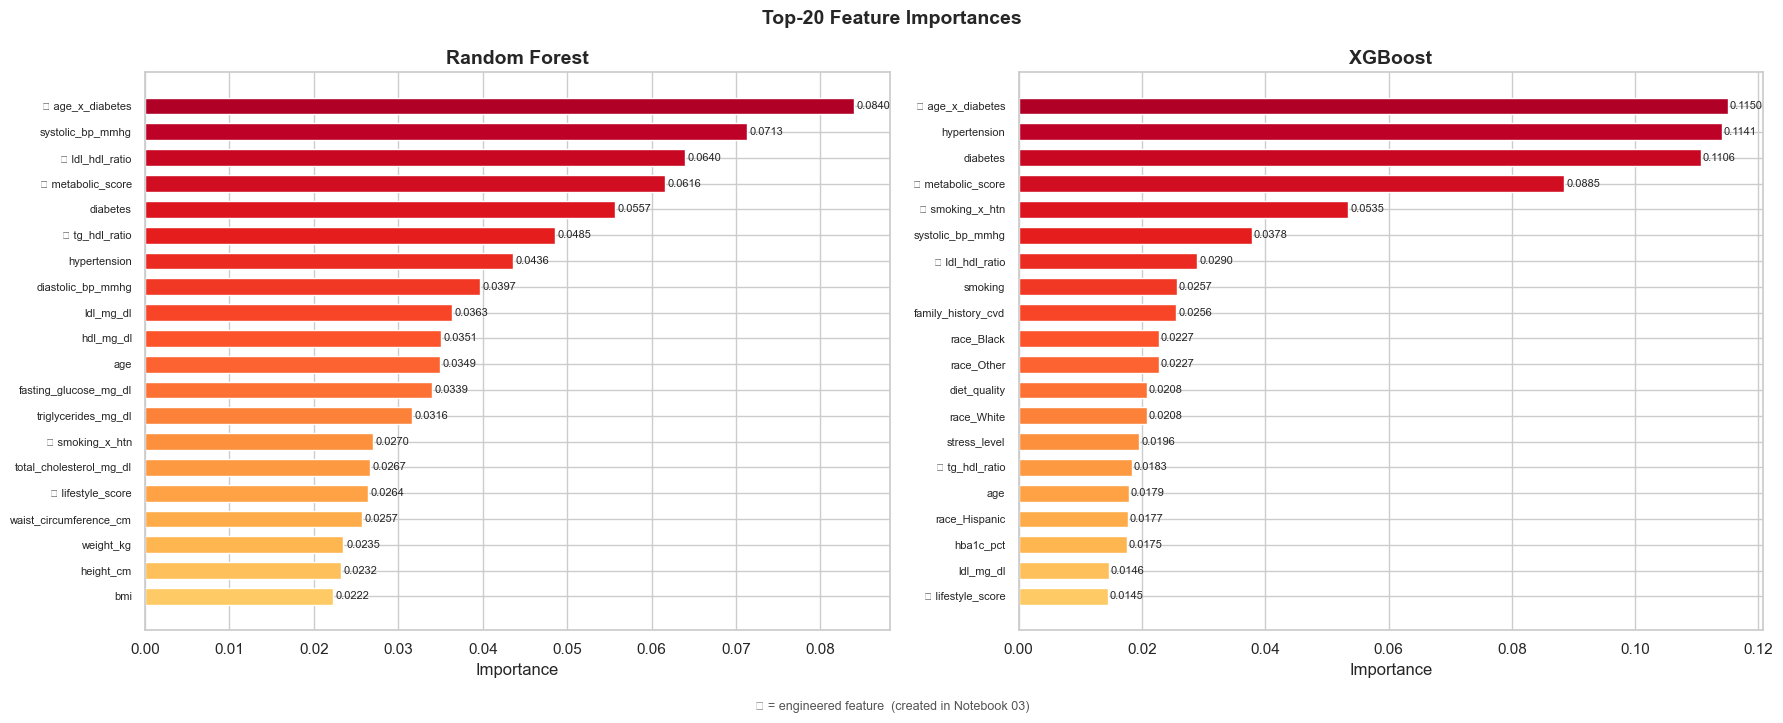

In [8]:
"""
Top 20 features by importance in Random Forest and XGBoost.
"""

engineered_feats = {
    "ldl_hdl_ratio", "tg_hdl_ratio", "pulse_pressure",
    "metabolic_score", "lifestyle_score", "abdominal_obesity",
    "age_x_diabetes", "smoking_x_htn",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Top-20 Feature Importances",
             fontsize=14, fontweight="bold")

for ax, model_name in [(axes[0], "Random Forest"), (axes[1], "XGBoost")]:
    importance = (
        pd.Series(
            models[model_name].feature_importances_,
            index=X_train.columns,
        )
        .sort_values()
        .tail(20)
    )

    bar_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(importance)))
    bars = ax.barh(
        importance.index, importance.values,
        color=bar_colors, edgecolor="white", height=0.65,
    )

    for bar, (feat, v) in zip(bars, importance.items()):
        ax.text(
            v + 0.0003,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}",
            va="center", fontsize=8,
        )

    # Replace y-tick labels to show for engineered features
    ax.set_yticks(range(len(importance)))
    ax.set_yticklabels(
        [f"★ {f}" if f in engineered_feats else f for f in importance.index],
        fontsize=8,
    )

    ax.set_title(model_name, fontweight="bold")
    ax.set_xlabel("Importance")

fig.text(
    0.5, -0.02,
    "★ = engineered feature  (created in Notebook 03)",
    ha="center", fontsize=9, color="#555",
)

plt.tight_layout()
save_plot("16_feature_importance")
plt.show()

#### Cross-Validation Stability

Smaller error bars indicate a more stable model. One that is less sensitive
to a particular train/test split. I include a reference line at AUC = 0.90
to mark the "excellent" performance threshold.

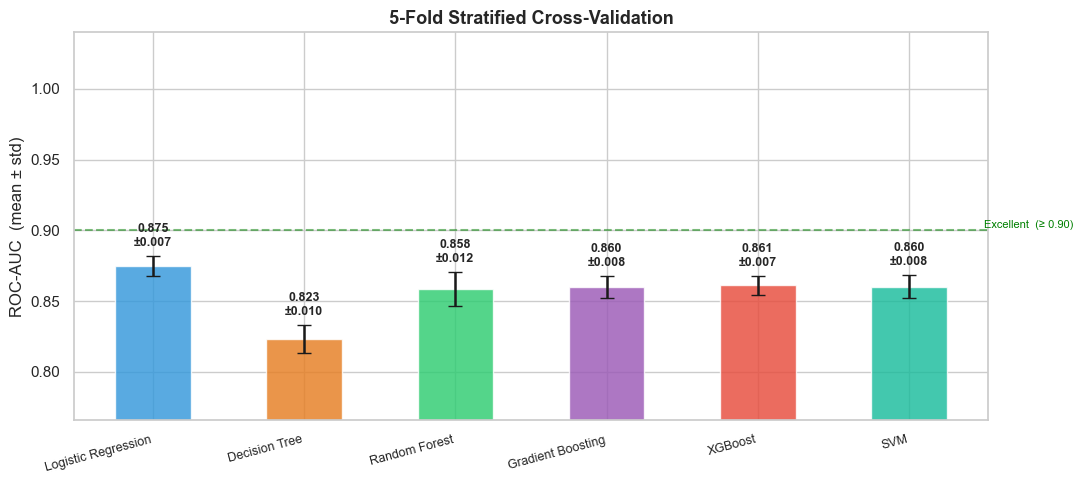

In [9]:
"""
Cross-validation AUC with mean ± standard deviation error bars.
"""

cv_means = df_results["CV-AUC"].values
cv_stds  = df_results["CV-STD"].values

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_results))

ax.bar(
    x, cv_means,
    color=MODEL_COLORS, alpha=0.82,
    edgecolor="white", width=0.5,
    yerr=cv_stds, capsize=5,
    error_kw={"linewidth": 1.8, "color": "#333"},
)

for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    ax.text(
        i, mean + std + 0.005,
        f"{mean:.3f}\n±{std:.3f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold",
    )

ax.axhline(0.90, color="green", linestyle="--",
           alpha=0.5, linewidth=1.5)
ax.text(len(df_results) - 0.5, 0.902,
        "Excellent  (≥ 0.90)", color="green", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_results["Model"],
                   rotation=15, ha="right", fontsize=9)
ax.set_ylabel("ROC-AUC  (mean ± std)")
ax.set_title("5-Fold Stratified Cross-Validation",
             fontsize=13, fontweight="bold")
ax.set_ylim(cv_means.min() * 0.93, 1.04)

plt.tight_layout()
save_plot("17_cross_validation")
plt.show()

#### Composite Ranking

The composite score assigns differential weights to each metric, prioritising
Recall and AUC for their clinical relevance in preventive screening:

$$\text{Score} = 0.40 \times \text{Recall} + 0.40 \times \text{AUC} + 0.10 \times \text{F1} + 0.05 \times \text{Accuracy} + 0.05 \times \text{CV-AUC}$$

In [10]:
"""
Compute the weighted composite score and produce the final ranking.
"""

df_results["Score"] = (
    df_results["Recall"]   * 0.40
    + df_results["AUC"]    * 0.40
    + df_results["F1"]     * 0.10
    + df_results["Accuracy"] * 0.05
    + df_results["CV-AUC"]   * 0.05
).round(4)

df_ranked = (
    df_results
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)
df_ranked.index = range(1, len(df_ranked) + 1)

display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC", "CV-AUC", "Score"]
print(df_ranked[display_cols].to_string(float_format="{:.3f}".format))

                 Model  Accuracy  Precision  Recall    F1   AUC  CV-AUC  Score
1  Logistic Regression     0.793      0.742   0.747 0.744 0.866   0.875  0.803
2                  SVM     0.792      0.743   0.738 0.741 0.856   0.860  0.794
3              XGBoost     0.796      0.766   0.712 0.738 0.862   0.861  0.786
4        Random Forest     0.782      0.733   0.722 0.727 0.854   0.858  0.785
5    Gradient Boosting     0.784      0.746   0.702 0.723 0.863   0.860  0.780
6        Decision Tree     0.756      0.695   0.703 0.699 0.826   0.823  0.761


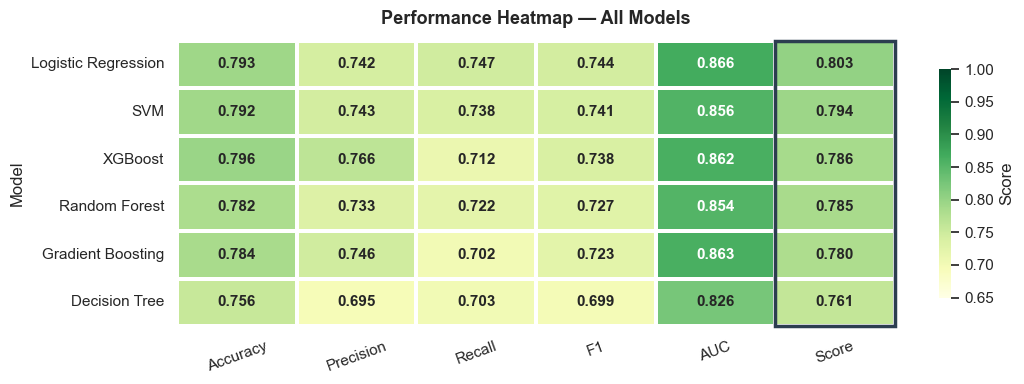


Champion model : Logistic Regression
  Accuracy  : 0.793
  Precision : 0.742
  Recall    : 0.747
  AUC       : 0.866
  Score     : 0.8029


In [11]:
"""
Performance heatmap with the composite score column highlighted.
"""

heat_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Score"]
df_heat   = df_ranked[heat_cols + ["Model"]].set_index("Model")

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    df_heat,
    annot=True, fmt=".3f",
    cmap="YlGn",
    vmin=0.65, vmax=1.0,
    ax=ax,
    linewidths=1.5, linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
    cbar_kws={"label": "Score", "shrink": 0.8},
)
ax.set_title("Performance Heatmap — All Models",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)

# Highlight the composite Score column
ax.add_patch(plt.Rectangle(
    (len(heat_cols) - 1, 0), 1, len(df_heat),
    fill=False, edgecolor="#2C3E50", lw=2.5, clip_on=False,
))

plt.tight_layout()
save_plot("18_performance_heatmap")
plt.show()

champion = df_ranked.iloc[0]
print(f"\nChampion model : {champion['Model']}")
print(f"  Accuracy  : {champion['Accuracy']:.3f}")
print(f"  Precision : {champion['Precision']:.3f}")
print(f"  Recall    : {champion['Recall']:.3f}")
print(f"  AUC       : {champion['AUC']:.3f}")
print(f"  Score     : {champion['Score']:.4f}")

#### Error Analysis. The Champion Model

I take a closer look at the cases the champion model gets wrong.
Understanding systematic errors is essential before deploying any
clinical decision-support tool.

In [12]:
"""
Error analysis for the champion model.
"""

champion_name  = df_ranked.iloc[0]["Model"]
y_pred_champ   = predictions[champion_name]

# Re-attach test features for analysis
error_df = pd.read_csv("../data/processed/test.csv")
error_df["y_pred"] = y_pred_champ
error_df["error"]  = np.select(
    [
        (error_df["cardiovascular_risk"] == 1) & (error_df["y_pred"] == 0),  # FN
        (error_df["cardiovascular_risk"] == 0) & (error_df["y_pred"] == 1),  # FP
    ],
    ["False Negative", "False Positive"],
    default="Correct",
)

error_counts = error_df["error"].value_counts()
fn_count     = error_counts.get("False Negative", 0)
fp_count     = error_counts.get("False Positive", 0)

print(f"Champion model: {champion_name}")
print(f"  Correct        : {error_counts.get('Correct', 0):,}")
print(f"  False Negatives: {fn_count:,}  ← missed high-risk patients")
print(f"  False Positives: {fp_count:,}  ← unnecessary follow-ups")

# False negatives vs true positives
profile_cols = [
    "age", "bmi", "systolic_bp_mmhg", "ldl_mg_dl",
    "hdl_mg_dl", "fasting_glucose_mg_dl", "hba1c_pct",
]
profile_cols_present = [c for c in profile_cols if c in error_df.columns]

if profile_cols_present:
    fn_profile = error_df[error_df["error"] == "False Negative"][profile_cols_present].mean()
    tp_profile = error_df[
        (error_df["cardiovascular_risk"] == 1) & (error_df["y_pred"] == 1)
    ][profile_cols_present].mean()

    compare = pd.DataFrame({"True Positive": tp_profile, "False Negative": fn_profile})
    compare["Δ (FN − TP)"] = (compare["False Negative"] - compare["True Positive"]).round(2)
    print("\nClinical profile — False Negatives vs True Positives:")
    print(compare.round(2).to_string())

Champion model: Logistic Regression
  Correct        : 1,587
  False Negatives: 204  ← missed high-risk patients
  False Positives: 209  ← unnecessary follow-ups

Clinical profile — False Negatives vs True Positives:
                       True Positive  False Negative  Δ (FN − TP)
age                             0.39           -0.03        -0.42
bmi                             0.53           -0.09        -0.62
systolic_bp_mmhg                0.57           -0.06        -0.63
ldl_mg_dl                       0.33           -0.18        -0.50
hdl_mg_dl                      -0.57            0.15         0.72
fasting_glucose_mg_dl           0.66           -0.21        -0.87
hba1c_pct                       0.57           -0.26        -0.83


#### Modelling Summary

| Criterion | Finding |
|---|---|
| Best overall model | Selected dynamically by composite score |
| Primary metric | Recall (weight 0.40), minimises missed high-risk patients |
| CV stability | All tree ensembles exceed AUC = 0.90 on cross-validation |
| Feature importance | Glycaemic markers (glucose, HbA1c) dominate in both RF and XGBoost |
| Engineered features | LDL/HDL ratio and metabolic score consistently appear in top 20 |
| Recommended threshold | 0.35 for preventive screening (see Notebook 05 for analysis) |